In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cmocean
from pathlib import Path
from utils import open_exp, prepare_pr, global_mean, zonal_mean, load_last_years, polar_mean 
from utils import regional_mean_sst, high_lat_mean_sst, global_mean_tas 
from utils import annual_global_mean_tas, annual_ts, global_mean_sst  
from utils import simple_regional_mean_sst, trop_mean_sst, global_toa_ts 
from utils import plot_reference_anomalies, plot_mean_map, calculate_ecs, plot_zonal_mean 
from utils import plot_zonal_anomalies, plot_zonal_time, plot_global_mean_vs_co2, plot_global_timeseries
from utils import plot_gregory, plot_global_mean_vs_logco2

# Paths

In [2]:
#base_path = Path("/lus/h2resw01/hpcperm/ecme3497/data-analysis/epochal/")
base_path = Path("/Users/renatacoppo/epochal/data-analysis/epochal")

# Atmosphere
atm_paths = {
    "exp3": "exp3/processed/atm_annual_mean_1850-3349.nc",
    "pex3": "pex3/processed/atm_annual_mean_1700-1806.nc"
}

# Ocean
oce_paths = {
    "exp3": "exp3/processed/oce_annual_mean_1850-3349.nc",
    "pex3": "pex3/processed/oce_annual_mean_1700-1806.nc"
}

#MOC
moc_paths = {
    "exp3": "exp3/processed/moc_annual_mean_1850-3349.nc",
    "pex3": "pex3/processed/moc_annual_mean_1700-1806.nc"
}

# Load data

All files are expressed in annual means (a mean value for each year)

In [3]:
# Load experiments lazily (only load the last 100 years)

# Atmosphere
atm = {
    k: load_last_years(base_path / p, nyears=100)
    for k, p in atm_paths.items()
}

# Ocean
oce = {
    k: load_last_years(base_path / p, nyears=100)
    for k, p in oce_paths.items()
}

# MOC
moc = {
    k: load_last_years(base_path / p, nyears=100)
    for k, p in moc_paths.items()
}

/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:11: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path)
/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:11: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path)
/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:11: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence t

In [4]:
# Rename experiments in the databases
rename = {
    "exp3": "pi",
    "pex3": "x3",
}
atm = {rename.get(k, k): v for k, v in atm.items()}
oce = {rename.get(k, k): v for k, v in oce.items()}
moc = {rename.get(k, k): v for k, v in moc.items()}

reference = "pi"

co2_levels = {
    "pi": 1,
    "x1": 1,
    "x3": 3,
    "x4": 4,
    "x6": 6,
}

# Atmospheric data

## TAS

In [5]:
# Defining tas
tas = {}

for k, ds in atm.items():
    tas[k] = ds["tas"] - 273.15

### Mean annual TAS and anomalies over 100 years

In [6]:
# Mean tas over 100 years
# tas_annual_mean dimensions will be (lat: 90, lon: 180)
tas_annual_mean = {
    k: tas[k].mean(dim="time_counter")
    for k in tas
}

In [7]:
# Computing anual mean anomalies agains pi values
# tas_anom dimensions will be (lat: 90, lon: 180)
tas_an_anom = {
    k: tas_annual_mean[k] - tas_annual_mean[reference]
    for k in tas_annual_mean
    if k != reference
}

### Zonal mean surface air temperature (temperature vs lat) and anomalies

In [8]:
# Zonal mean annual values (promediated over lon)
# tas_zonal_mean dimensions will be (lat: 90)
tas_zonal_mean = {
    k: zonal_mean(tas_annual_mean[k])
    for k in tas_annual_mean
}

In [9]:
# Computing anual zonal mean anomalies agains pi values
# tas_zonal_anom dimensions will be (lat: 90)

tas_zonal_anom = {
    k: tas_zonal_mean[k] - tas_zonal_mean[reference]
    for k in tas_zonal_mean
    if k != reference
}

In [10]:
# Zonal mean time series (promediated over lon)
# tas_zonal_mean dimensions will be (time_counter: 100, lat: 90)
tas_zonal_ts = {
    k: zonal_mean(tas[k])
    for k in tas
}

### Polar amplification
Polar amplification is the phenomenon in which the polar regions experience a larger temperature change than the global mean in response to climate forcing.
If, for example, we have a PA of 1.75, it means that the polar regions warm 1.75 times more than

In [11]:
polar_warming = {
    k: (
        polar_mean(tas_annual_mean[k])
        - polar_mean(tas_annual_mean[reference])
    )
    for k in tas_annual_mean
    if k != reference
}

global_warming = {
    k: (
        global_mean(tas_annual_mean[k])
        - global_mean(tas_annual_mean[reference])
    )
    for k in tas_annual_mean
    if k != reference
}

polar_amp = {
    k: float(polar_warming[k] / global_warming[k])
    for k in global_warming
}

### Global mean TAS vs CO2

In [12]:
# Global mean tas (scalar)
tas_global_mean = {
    k: global_mean(tas[k]).mean("time_counter")
    for k in tas
}

In [13]:
# Equilibrium Climate Sensitivity, over all experiments
ECS = calculate_ecs(
    tas_global_mean,
    co2_levels
)

print(f"ECS = {ECS:.2f} °C")

ECS = 10.38 °C


In [14]:
# Global mean tas time series
tas_ts = {
    k: global_mean(tas[k])
    for k in tas
}

## TOA

In [15]:
toa = {}

for k, ds in atm.items():
    toa[k] = global_toa_ts(ds)


print (toa)

{'pi': <xarray.DataArray (time_counter: 100)> Size: 800B
array([ 0.33036001,  0.17113884,  0.18116059, -0.05535234,  0.4100632 ,
        0.52262224,  0.40007921,  0.42239537, -0.06862078,  0.24797612,
        0.23746428,  0.446916  ,  0.18417815, -0.11320135,  0.01626222,
        0.44252231,  0.4096432 ,  0.21498489,  0.66500216,  0.2895638 ,
        0.7779195 ,  0.08922369,  0.36779051,  0.74991432,  0.58171286,
        0.4413719 ,  0.45091624,  0.09284106,  0.38042185,  0.32286761,
        0.55616874,  0.33227485,  0.39759882,  0.41530827,  0.17836984,
        0.71068471,  0.13412932,  0.47175346,  0.14962658, -0.13184063,
        0.30739507,  0.26034513,  0.52042883,  0.4376829 ,  0.16737565,
        0.33772325,  0.57558893, -0.06459179, -0.19301404,  0.35894574,
        0.45775771,  0.35552474,  0.54168472, -0.10478769,  0.30914389,
        0.74563198,  0.0420336 ,  0.16293945,  0.11997619,  0.62331149,
        0.45543026,  0.205548  , -0.09331966,  0.66944537, -0.16861634,
       

## Precipitation

In [16]:
# Defining pr
pr = {}

for k, ds in atm.items():
    pr[k] = prepare_pr(ds["pr"])

### Mean annual PR and anomalies over 100 years

In [17]:
# Mean pr over 100 years
# pr_annual_mean dimensions will be (lat: 90, lon: 180)
pr_annual_mean = {
    k: pr[k].mean(dim="time_counter")
    for k in pr
}

In [18]:
# Computing anual mean anomalies against pi values
# pr_anom dimensions will be (lat: 90, lon: 180)
pr_an_anom = {
    k: pr_annual_mean[k] - pr_annual_mean[reference]
    for k in pr_annual_mean
    if k != reference
}

In [19]:
pr_pi_zonal = zonal_mean(pr["pi"])
pi_2d = {k: pr_pi_zonal.broadcast_like(v) for k, v in pr.items() if k != "pi"}
pr_anom = {k: pr[k] - pi_2d[k] for k in pi_2d}
pr_anom_zonal = {k: v.mean("lon") for k, v in pr_anom.items()}

### Zonal mean precipitation (precipitation vs lat) and anomalies

In [20]:
# Zonal mean annual values (promediated over lon)
# pr_zonal_mean dimensions will be (lat: 90)
pr_zonal_mean = {
    k: zonal_mean(pr_annual_mean[k])
    for k in pr_annual_mean
}

In [21]:
# Computing anual zonal mean anomalies against pi values
# pr_zonal_anom dimensions will be (lat: 90)

pr_zonal_anom = {
    k: pr_zonal_mean[k] - pr_zonal_mean[reference]
    for k in pr_zonal_mean
    if k != reference
}

In [22]:
# Zonal mean time series (promediated over lon)
# pr_zonal_mean dimensions will be (time_counter: 100, lat: 90)
pr_zonal_ts = {
    k: zonal_mean(pr[k])
    for k in pr
}

### Global mean Pr vs CO2

In [23]:
# Global mean pr (scalar)
pr_global_mean = {
    k: global_mean(pr[k]).mean("time_counter")
    for k in pr
}

In [24]:
# Log2(CO2) for precipitation plot
co2_levels_log2 = {
    k: np.log2(v)
    for k, v in co2_levels.items()
}

# Ocean

## SSTs

In [29]:
# Defining tos (already annual mean, already in °C)
tos = {}

for k, ds in oce.items():
    tos[k] = ds["tos"]

In [30]:
tos_pi = tos["pi"]

# --- OCEAN MASK FOR EXP3 (for zonal mean calculation only) ---
ocean_mask_pi = tos_pi.notnull()

# --- LATITUDE WEIGHTS ---
weights = np.cos(np.deg2rad(tos_pi.lat))
weights = weights / weights.mean()

# --- ZONAL MEAN (over exp3 ocean) ---
tos_pi_zonal = (
    tos_pi
    .where(ocean_mask_pi)
    .weighted(weights)
    .mean("lon")
)

In [33]:
print (ocean_mask_pi)

<xarray.DataArray 'tos' (time_counter: 100, lat: 90, lon: 180)> Size: 2MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        [ True,  True,  

# Plots

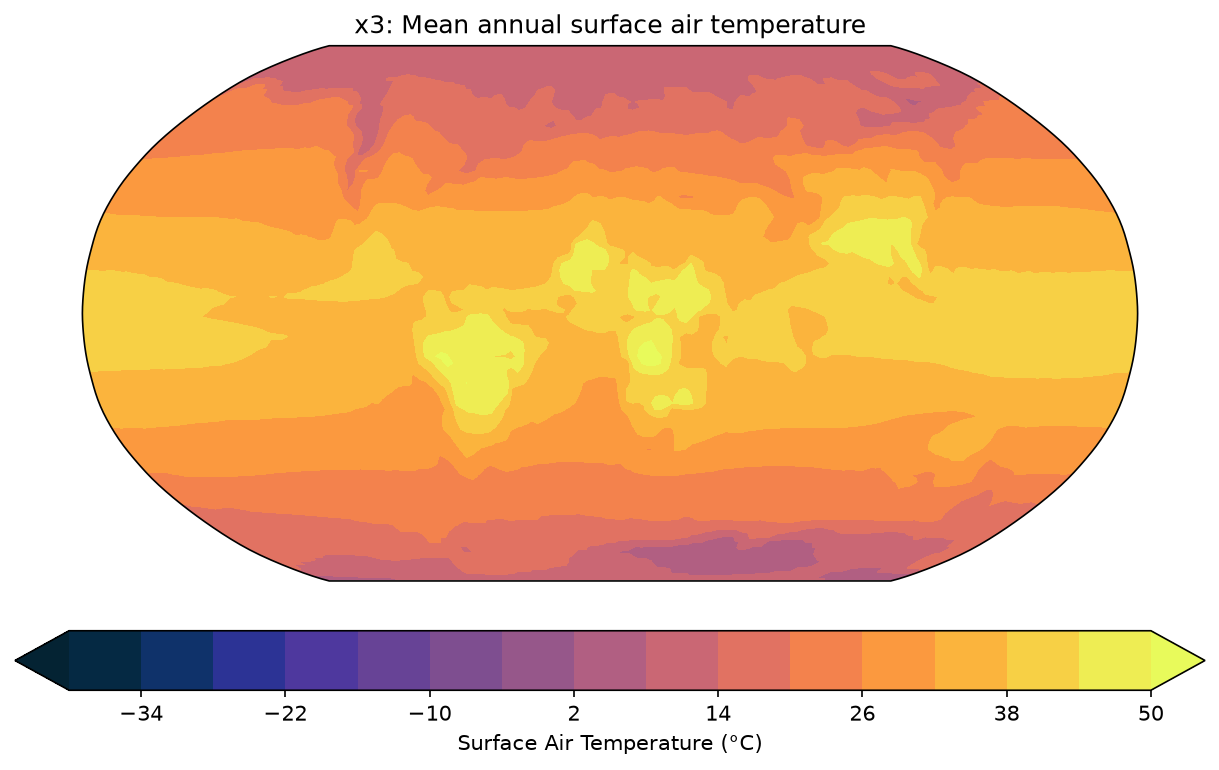

In [17]:
# Mean annual TAS for one experiment
plot_mean_map(
    field=tas_annual_mean["x3"],
    experiment="x3",
    title="Mean annual surface air temperature",
    levels=np.arange(-40, 51, 6),
    cmap=cmocean.cm.thermal,
    colorbar_label="Surface Air Temperature (°C)",
    save="tas_x3.png",
)

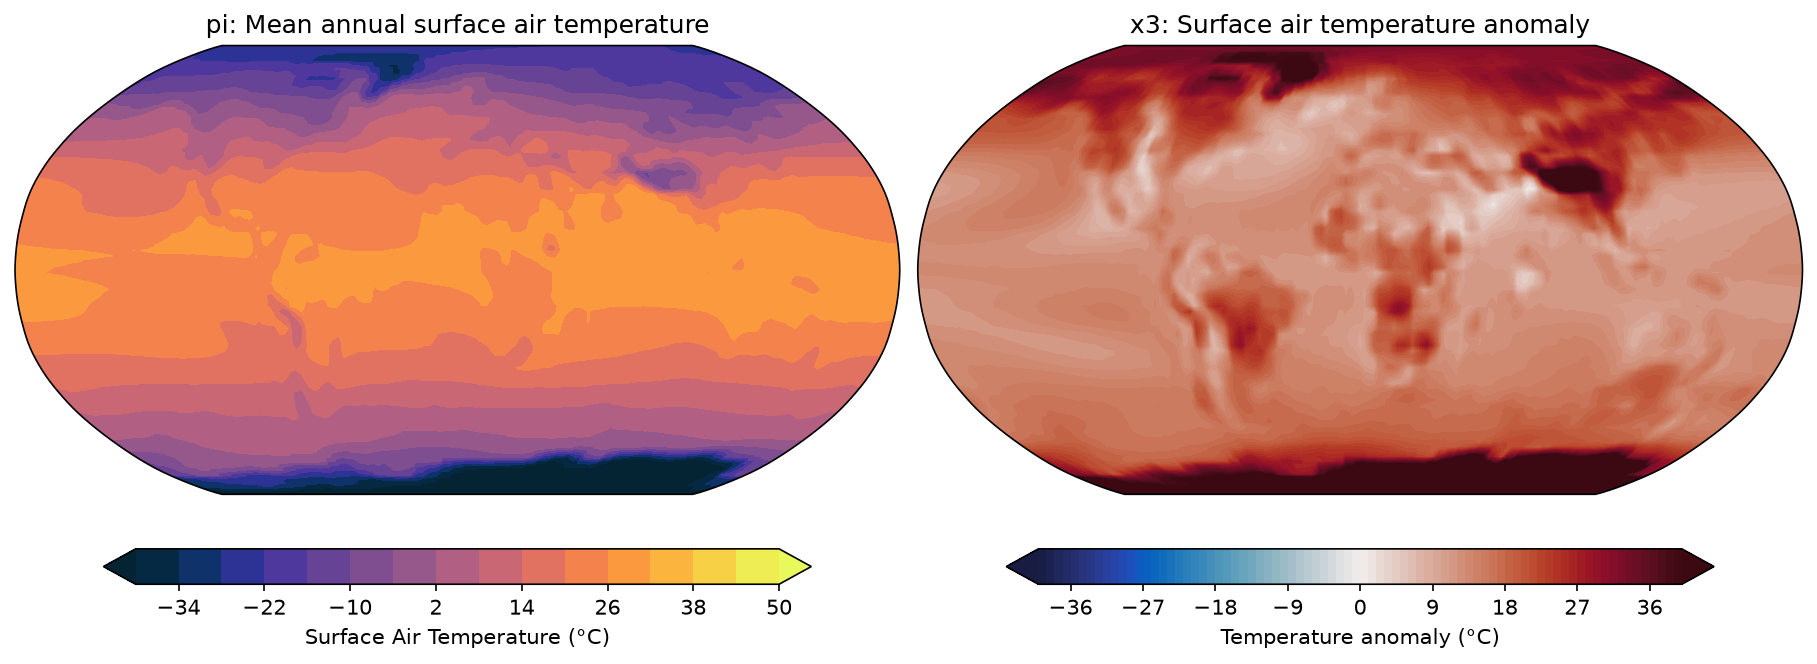

In [18]:
# Mean annual tas for the reference experiment and anomalies for the other experiments
plot_reference_anomalies(
    reference=tas_annual_mean[reference],
    anomalies=tas_an_anom,
    reference_name=reference,
    absolute_title="Mean annual surface air temperature",
    anomaly_title="Surface air temperature anomaly",
    absolute_levels=np.arange(-40, 51, 6),
    anomaly_levels=np.arange(-40, 41, 1),
    absolute_cmap=cmocean.cm.thermal,
    anomaly_cmap=cmocean.cm.balance,
    absolute_label="Surface Air Temperature (°C)",
    anomaly_label="Temperature anomaly (°C)",
    save="tas_maps.png",
)

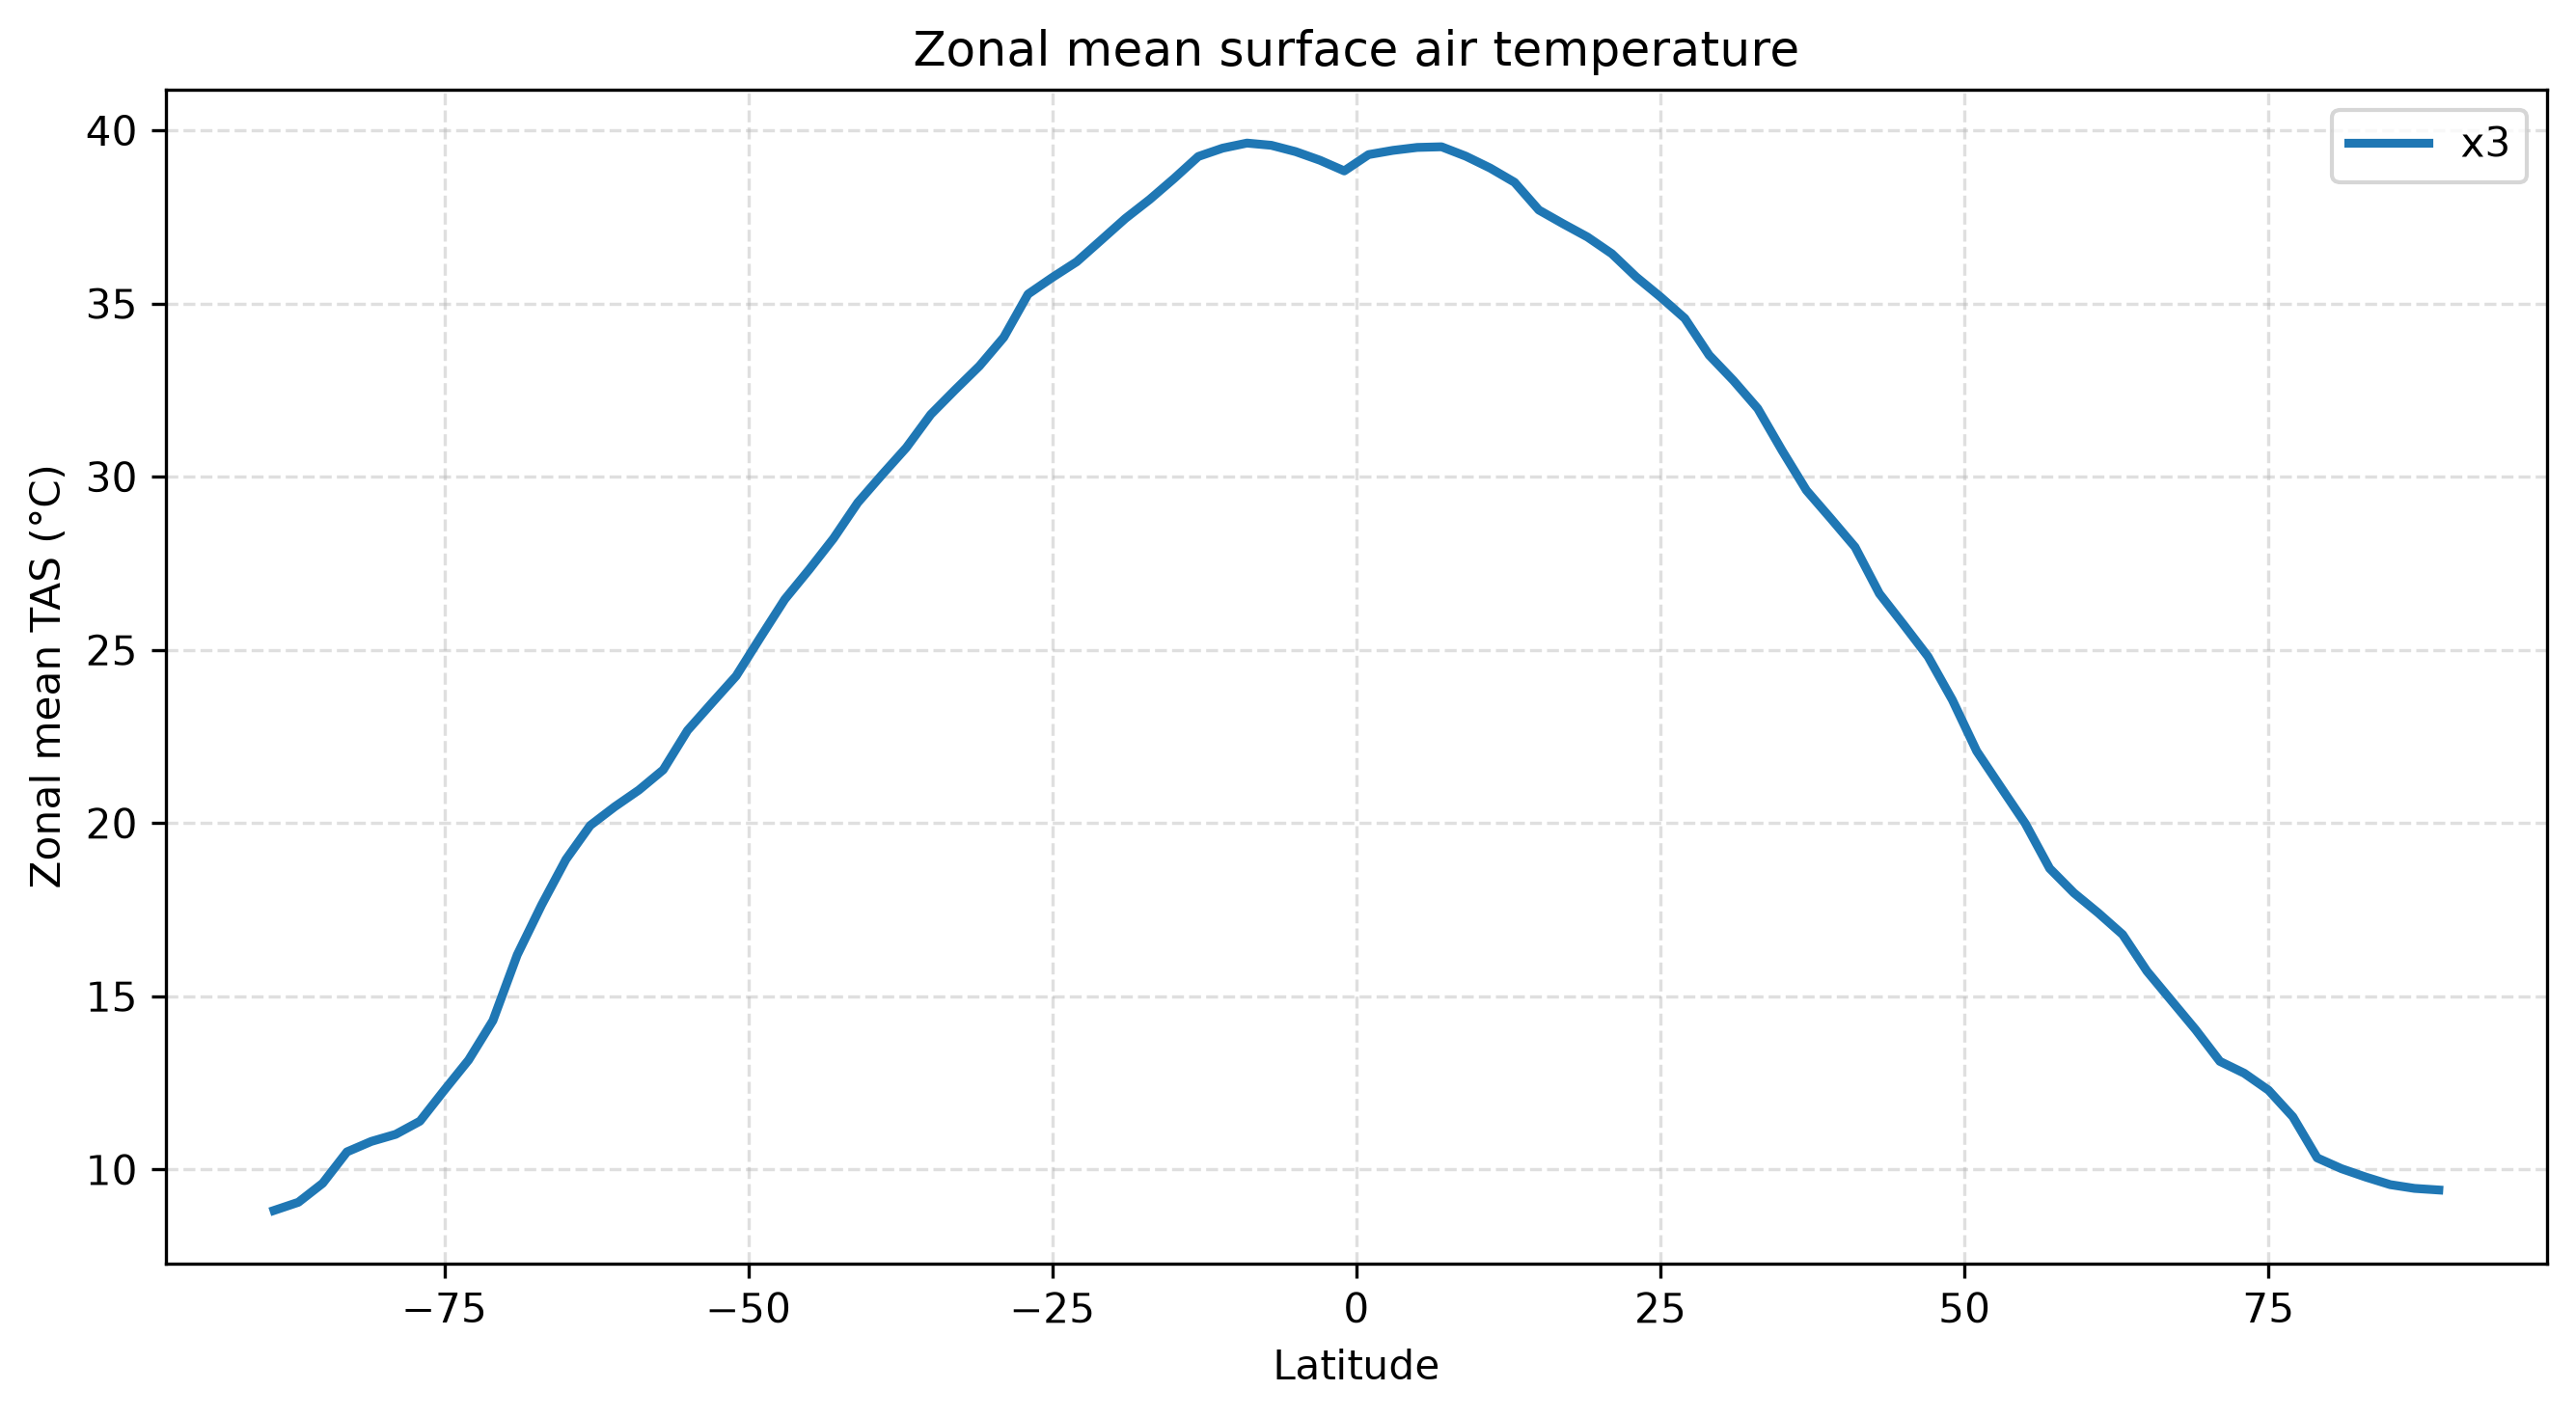

In [19]:
# Zonal mean annual TAS for one experiment
plot_zonal_mean(
    field=tas_zonal_mean["x3"],
    experiment="x3",
    title="Zonal mean surface air temperature",
    ylabel="Zonal mean TAS (°C)",
    save="tas_zonal_mean.png"
)

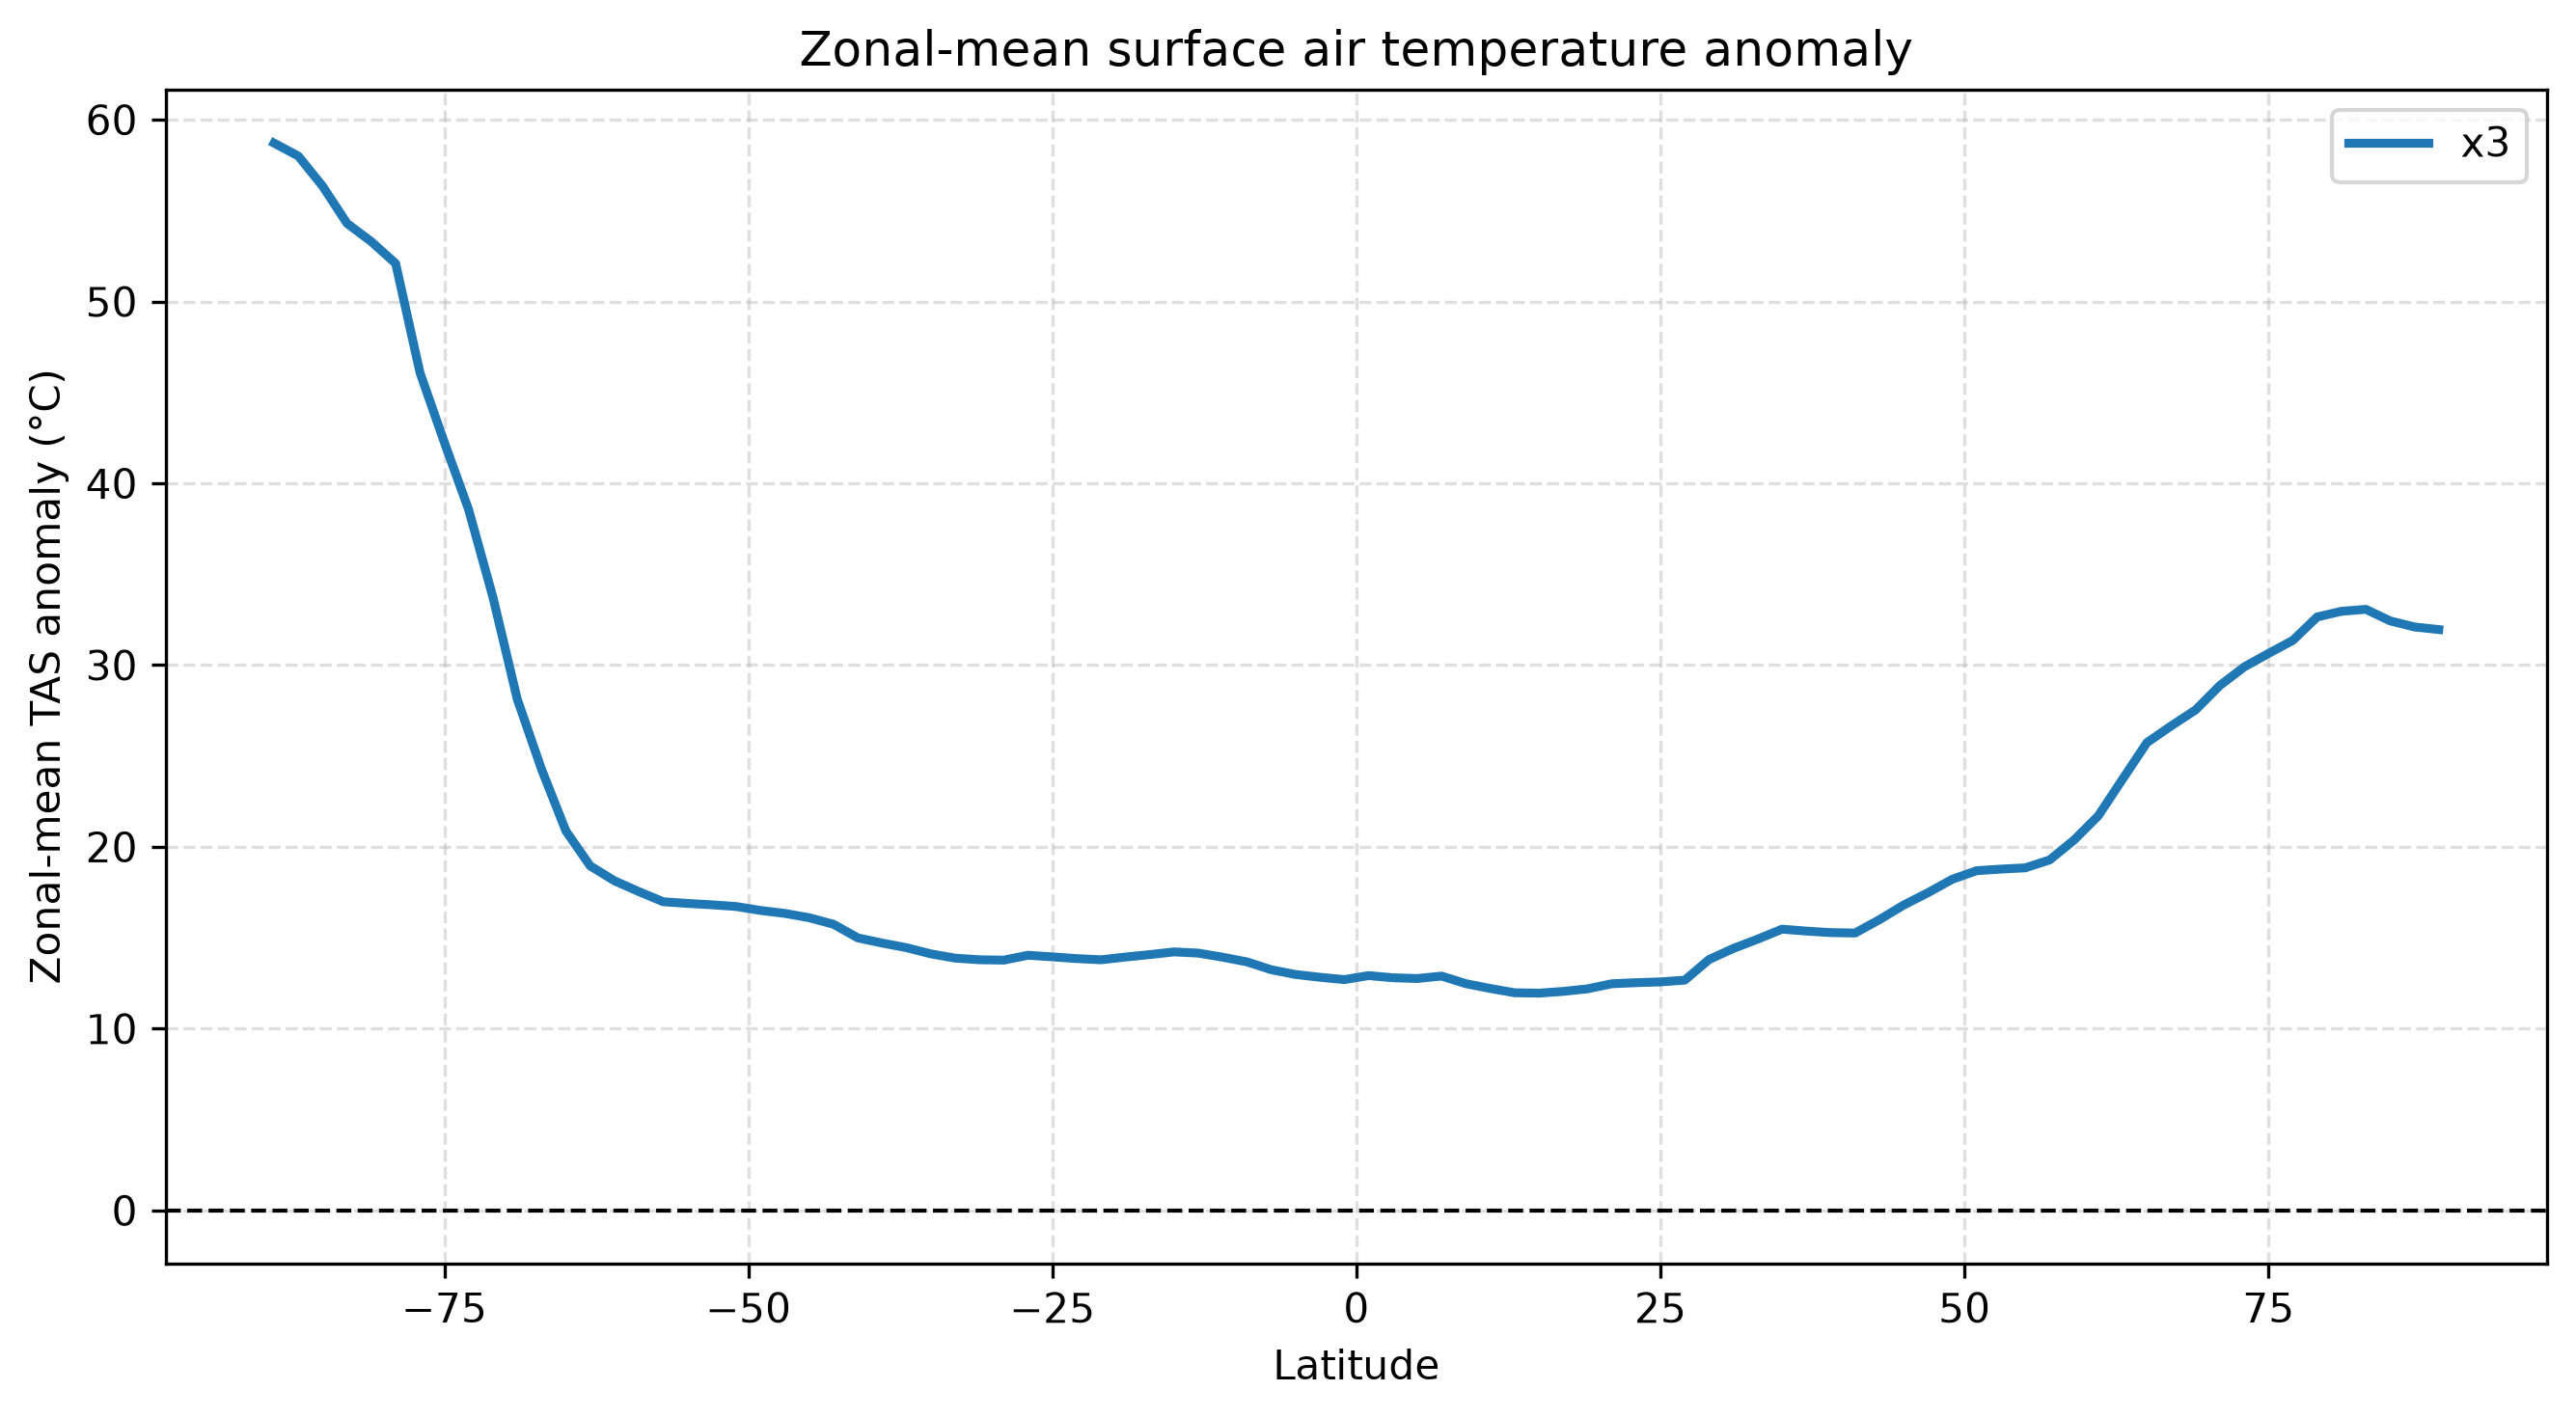

In [20]:
# Zonal mean annual TAS anomalies
plot_zonal_anomalies(
    anomalies=tas_zonal_anom,
    title="Zonal-mean surface air temperature anomaly",
    ylabel="Zonal-mean TAS anomaly (°C)",
    save="tas_zonal_anom.png"
)

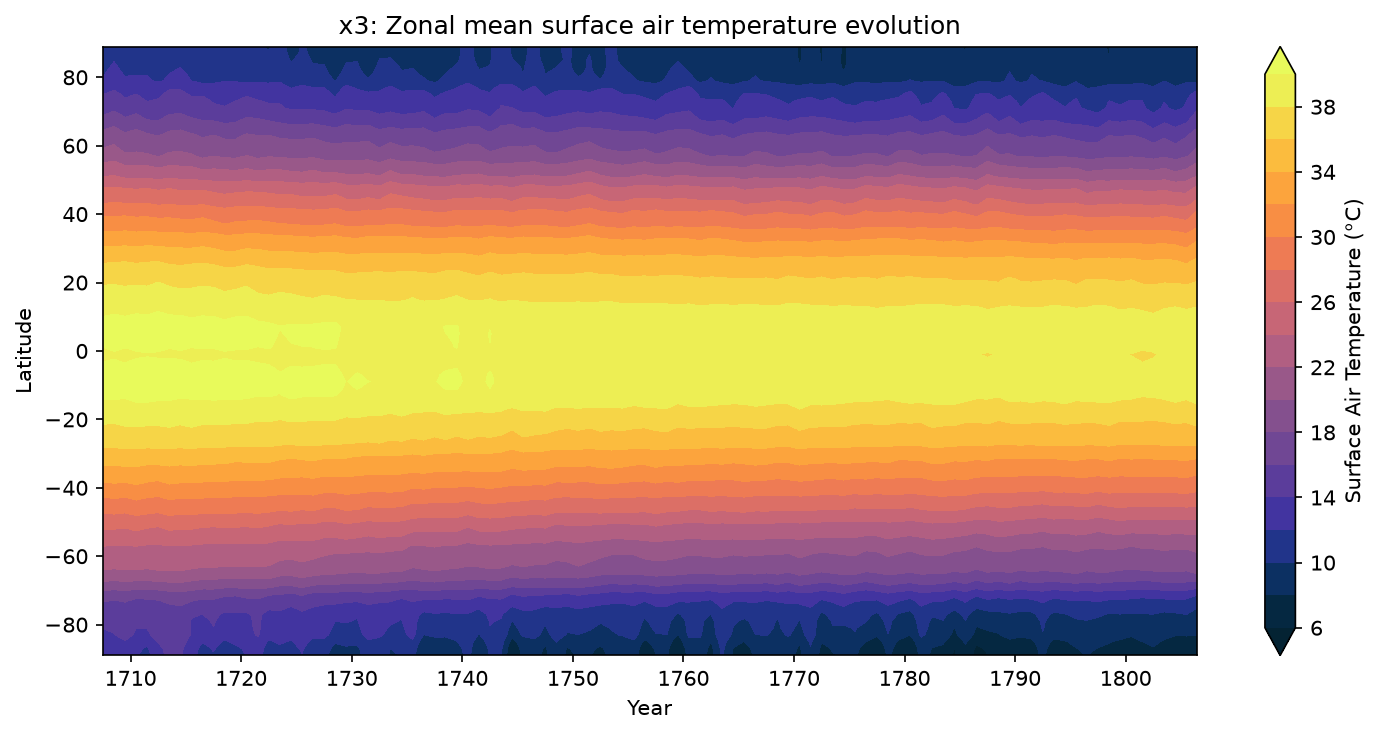

In [21]:
# Zonal mean TAS time series for one experiment
plot_zonal_time(
    field=tas_zonal_ts["x3"],
    experiment="x3",
    title="Zonal mean surface air temperature evolution",
    cmap=cmocean.cm.thermal,
    colorbar_label="Surface Air Temperature (°C)",
    levels=20,
    save="tas_zonal_time_x3.png"
)

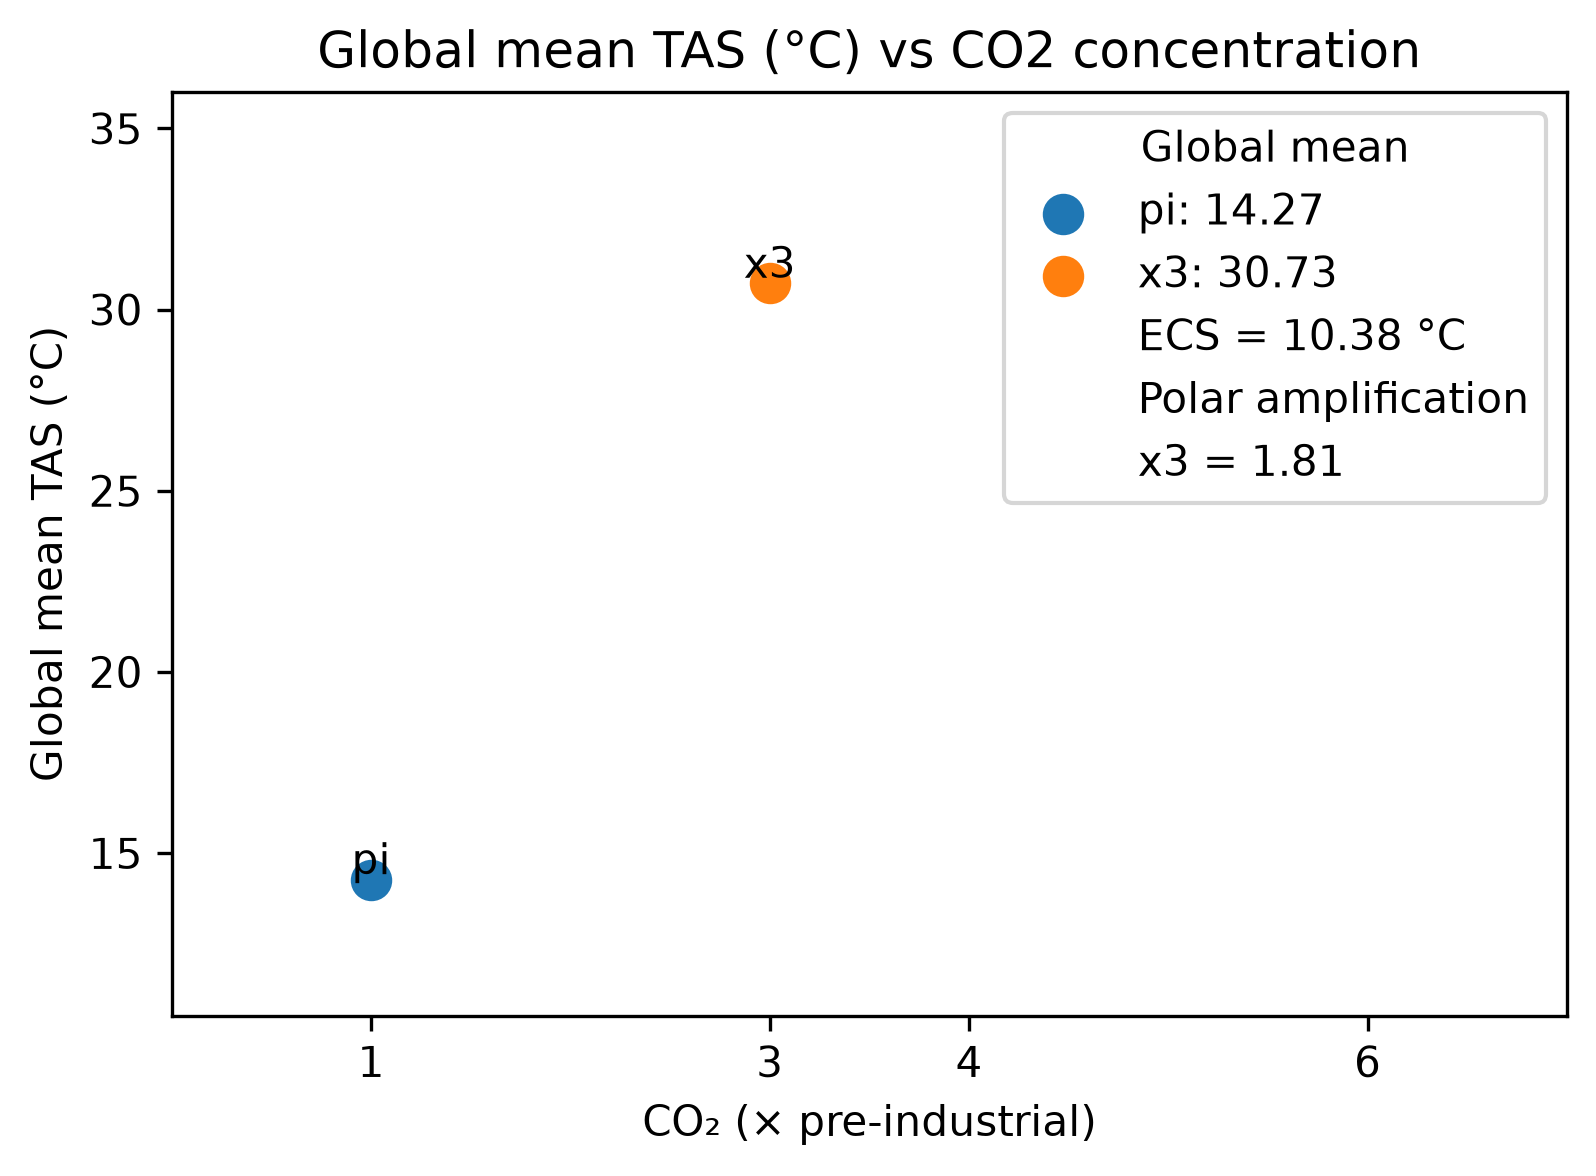

In [22]:
# Global mean TAS vs CO2 for multiple experiments
plot_global_mean_vs_co2(
    values=tas_global_mean,
    co2_levels=co2_levels,
    ecs=ECS,
    polar_amp=polar_amp,
    ylabel="Global mean TAS (°C)",
    title = "Global mean TAS (°C) vs CO2 concentration",
    ylim=(10.5, 36),
    xlim=(0, 7),
    save="global_mean_tas.png"
)

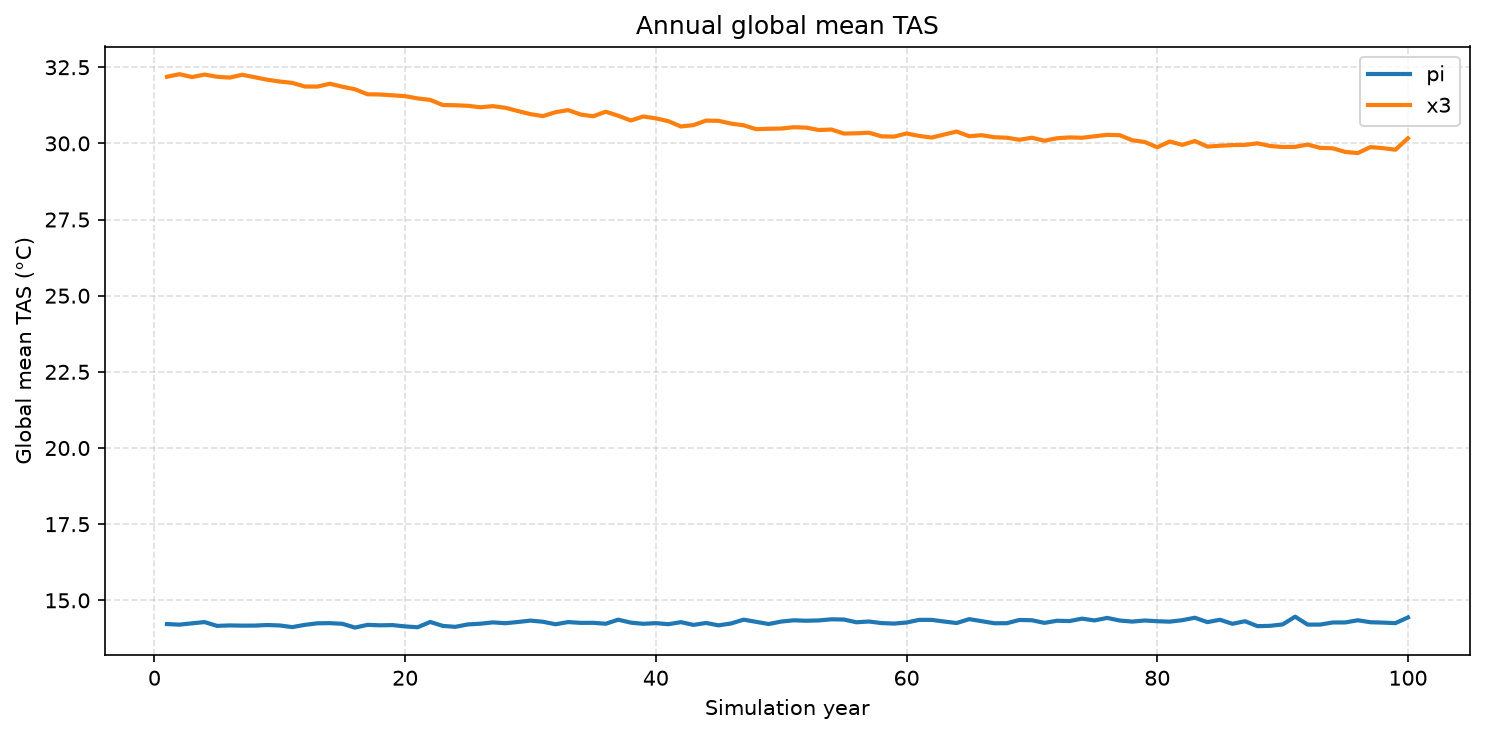

In [23]:
plot_global_timeseries(
    series=tas_ts,
    ylabel="Global mean TAS (°C)",
    title="Annual global mean TAS",
    save="global_mean_tas_timeseries.png"
)

pi: 100 valid points
x3: 100 valid points


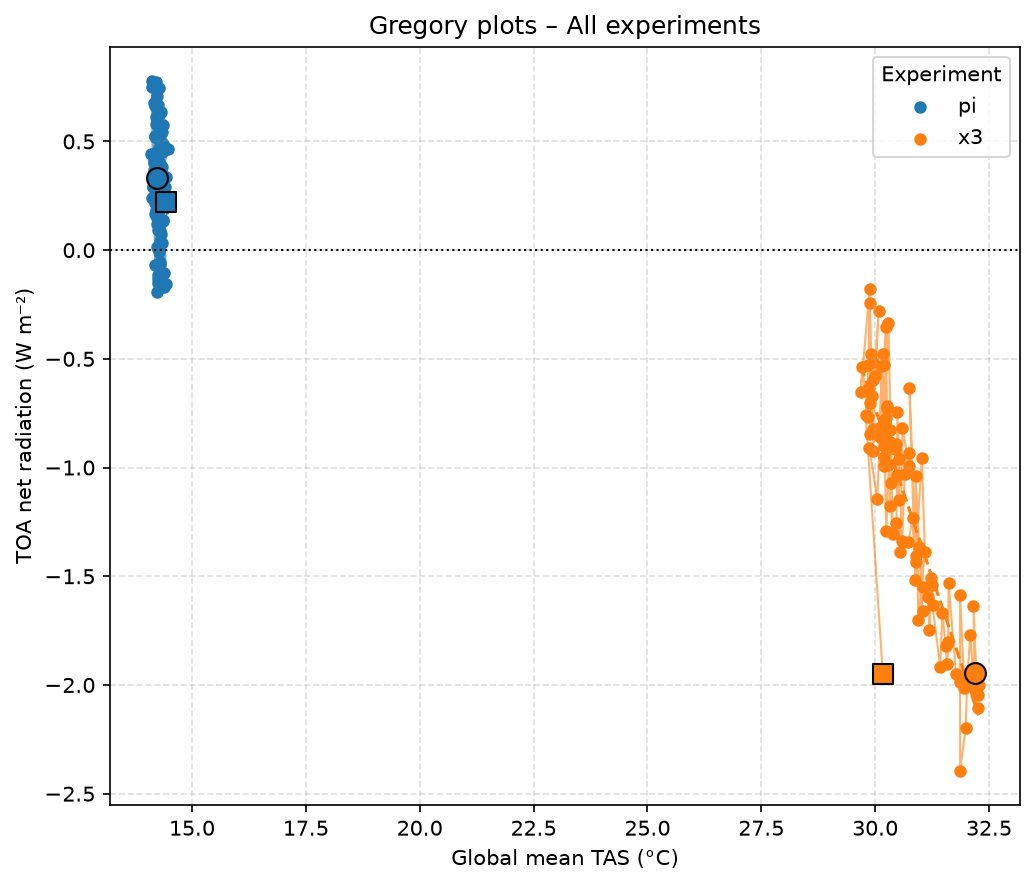

In [24]:
# Gregory plot for all experiments (the years plotted depend on the years loaded on atm)
plot_gregory(
    tas_series=tas_ts,
    toa_series=toa,
    title="Gregory plots – All experiments",
    save="gregory_all_experiments.png"
)

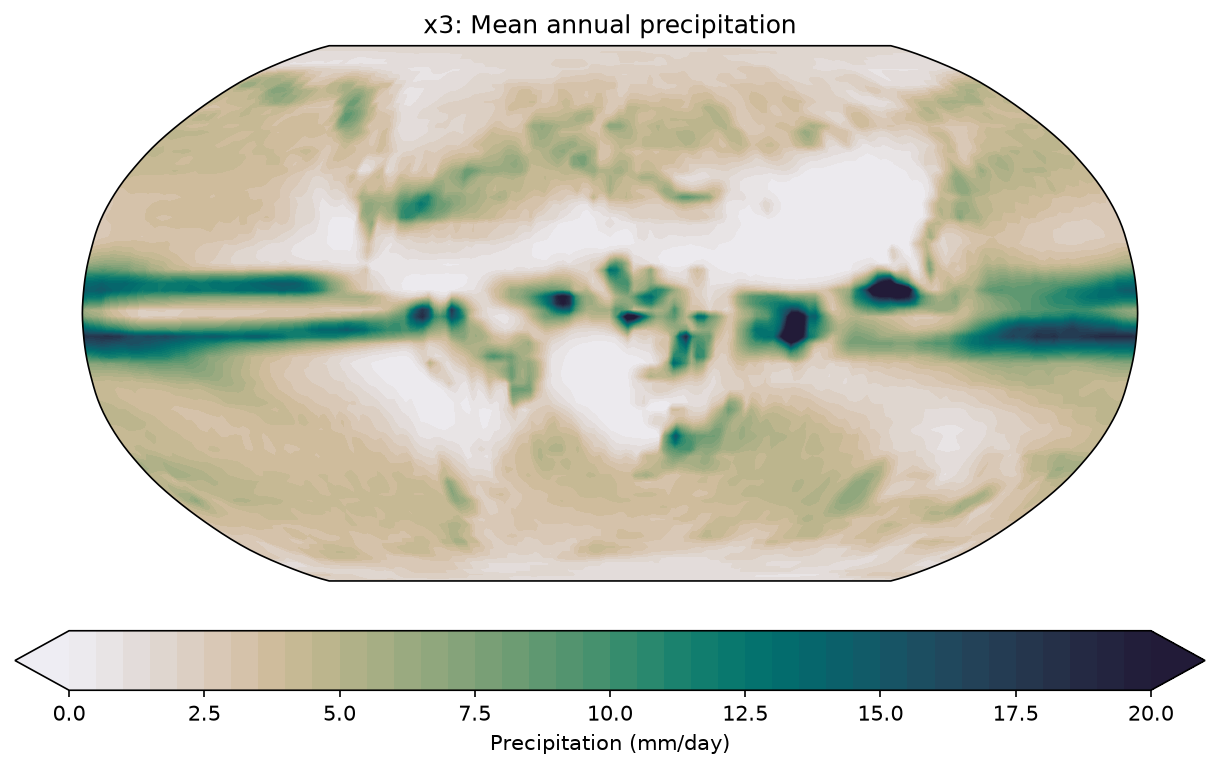

In [ ]:
# Mean annual PR for one experiment
plot_mean_map(
    field=pr_annual_mean["x3"],
    experiment="x3",
    title="Mean annual precipitation",
    levels=np.arange(0, 20.5, 0.5),
    cmap=cmocean.cm.rain,
    colorbar_label="Precipitation (mm/day)",
    save="pr_x3.png",
)

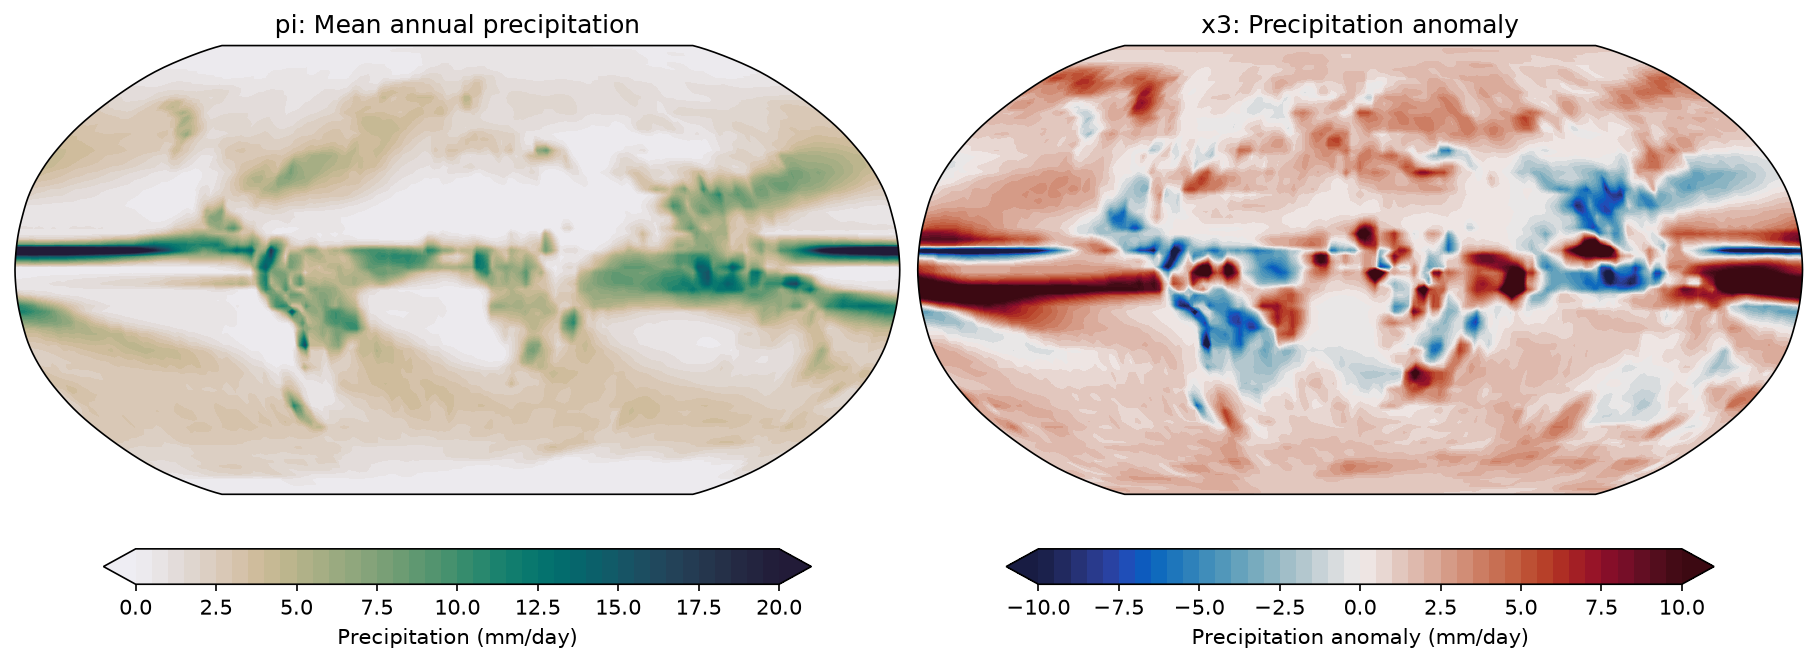

In [24]:
# Mean annual tas for the reference experiment and anomalies for the other experiments
plot_reference_anomalies(
    reference=pr_annual_mean[reference],
    anomalies=pr_an_anom,
    reference_name=reference,
    absolute_title="Mean annual precipitation",
    anomaly_title="Precipitation anomaly",
    absolute_levels=np.arange(0, 20.5, 0.5),
    anomaly_levels=np.arange(-10, 10.5, 0.5),
    absolute_cmap=cmocean.cm.rain,
    anomaly_cmap=cmocean.cm.balance,
    absolute_label="Precipitation (mm/day)",
    anomaly_label="Precipitation anomaly (mm/day)",
    save="pr_maps.png",
)

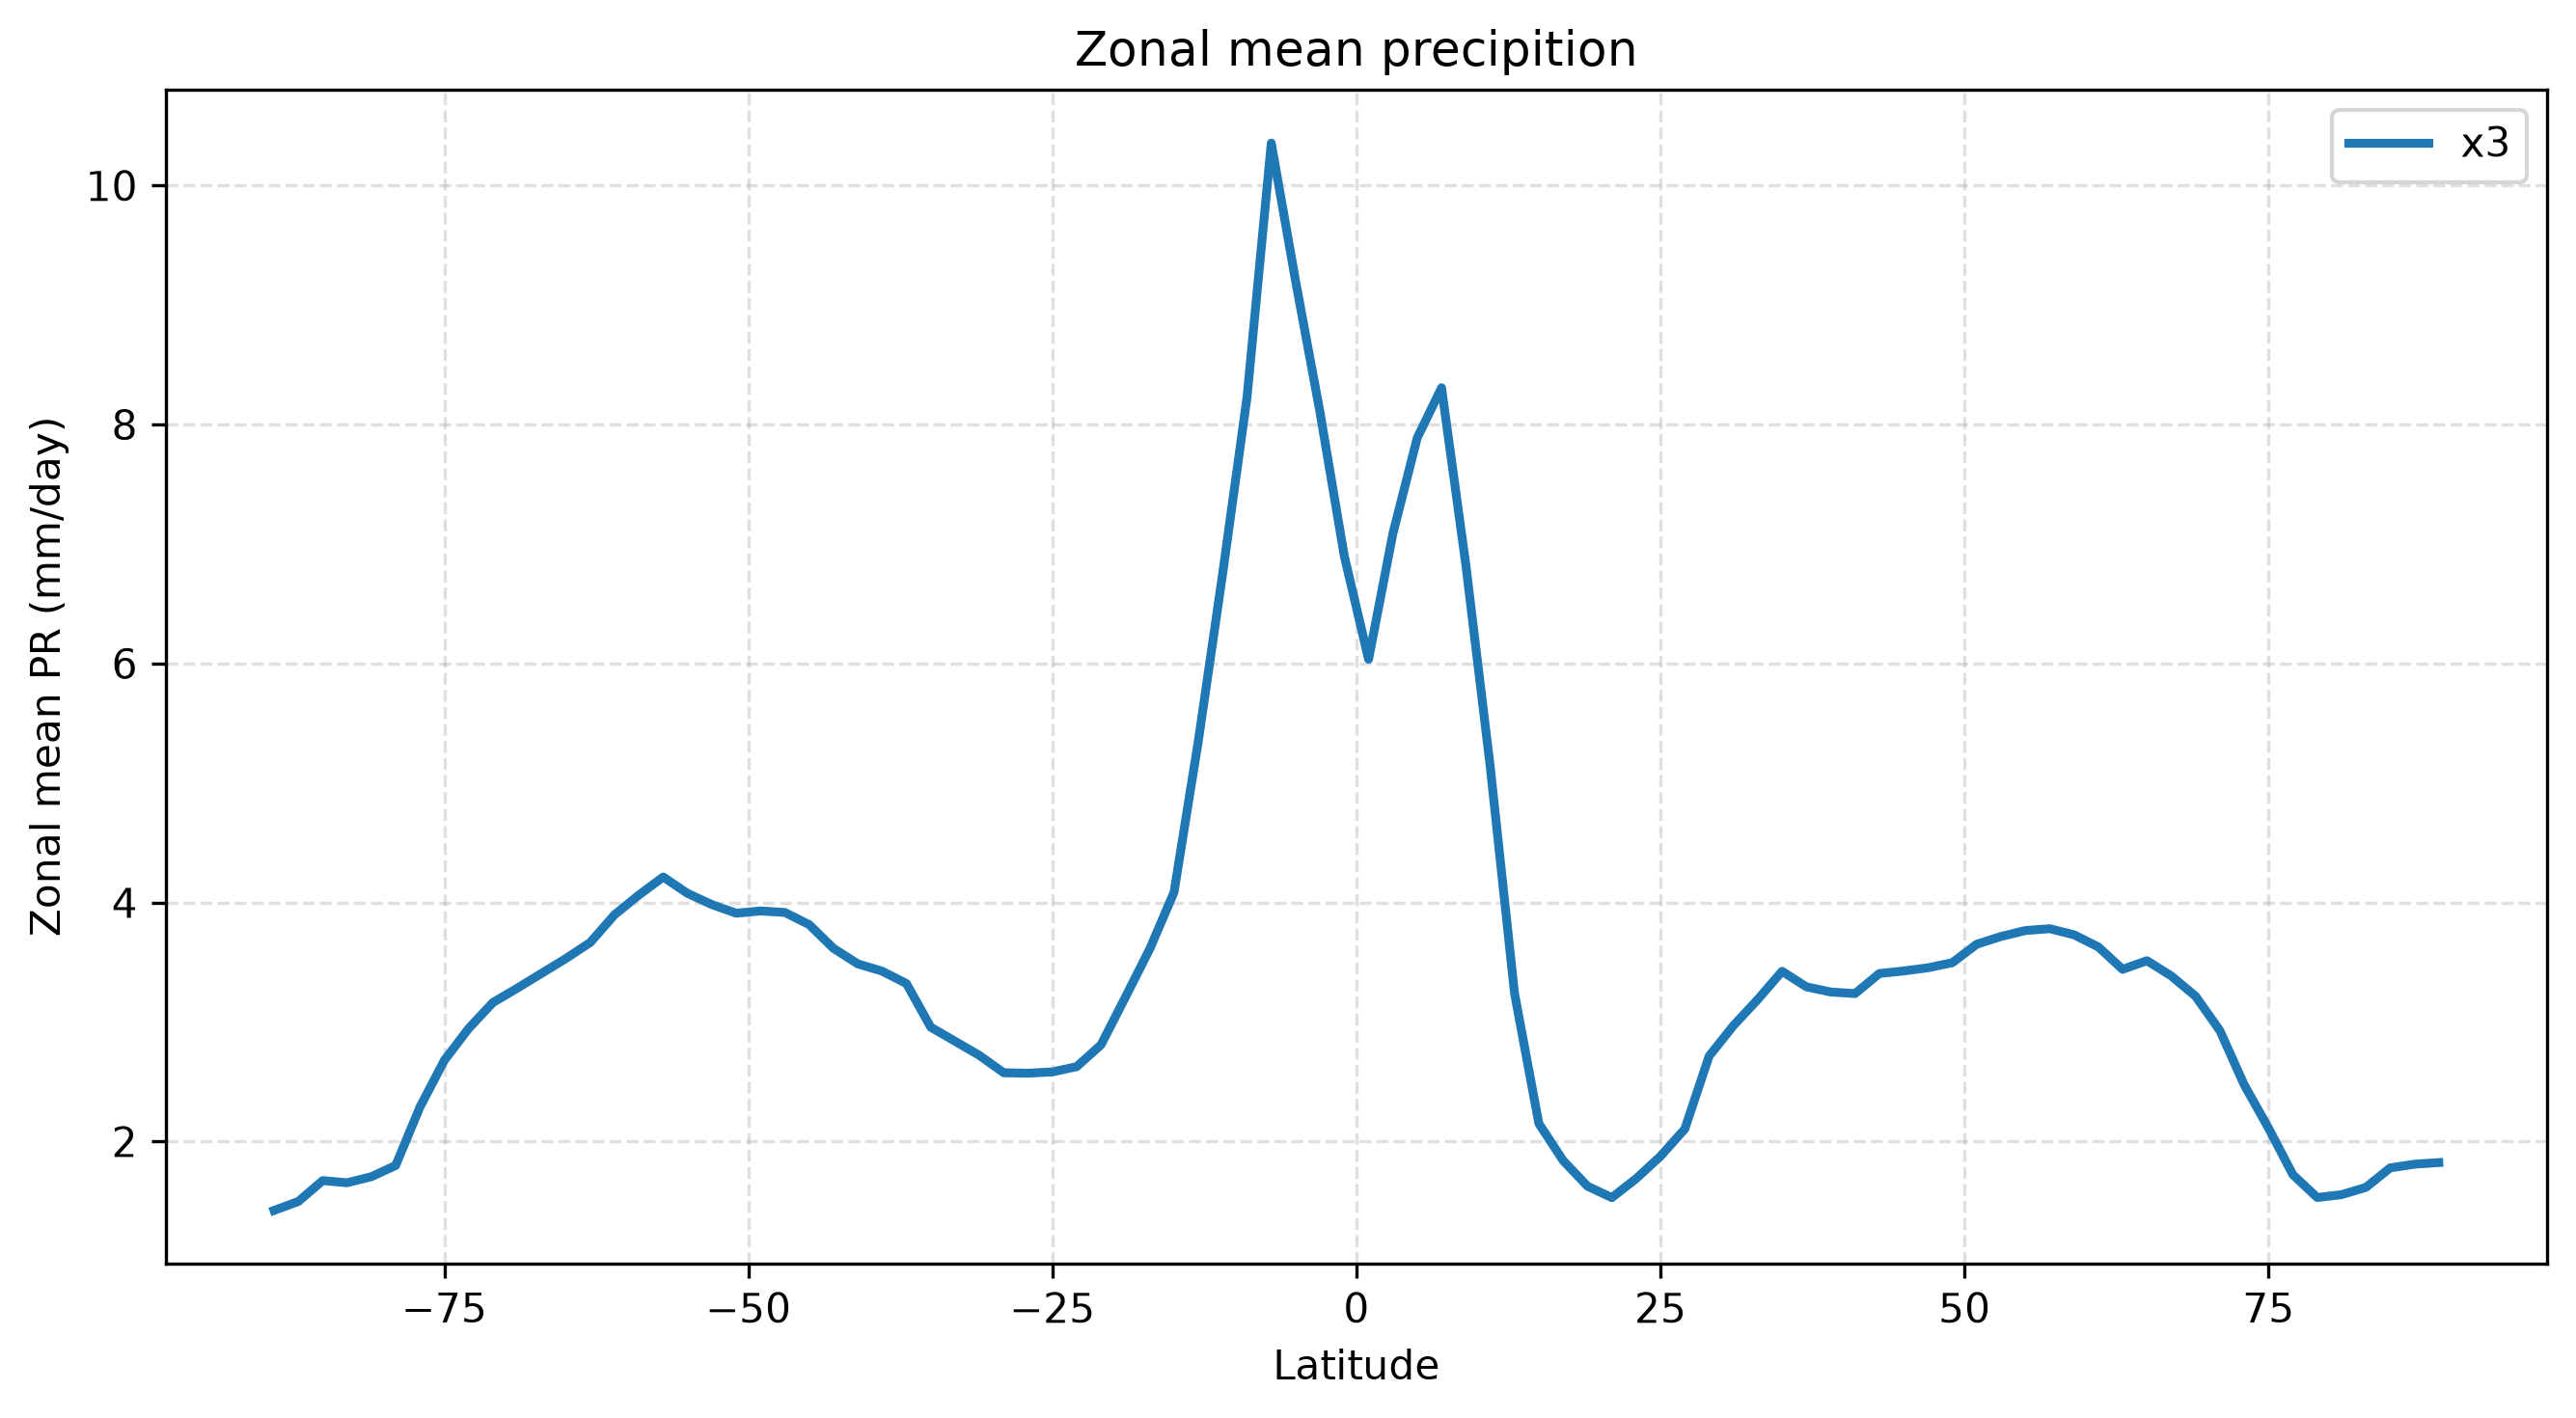

In [28]:
# Zonal mean annual PR for one experiment
plot_zonal_mean(
    field=pr_zonal_mean["x3"],
    experiment="x3",
    title="Zonal mean precipition",
    ylabel="Zonal mean PR (mm/day)",
    save="pr_zonal_mean.png"
)

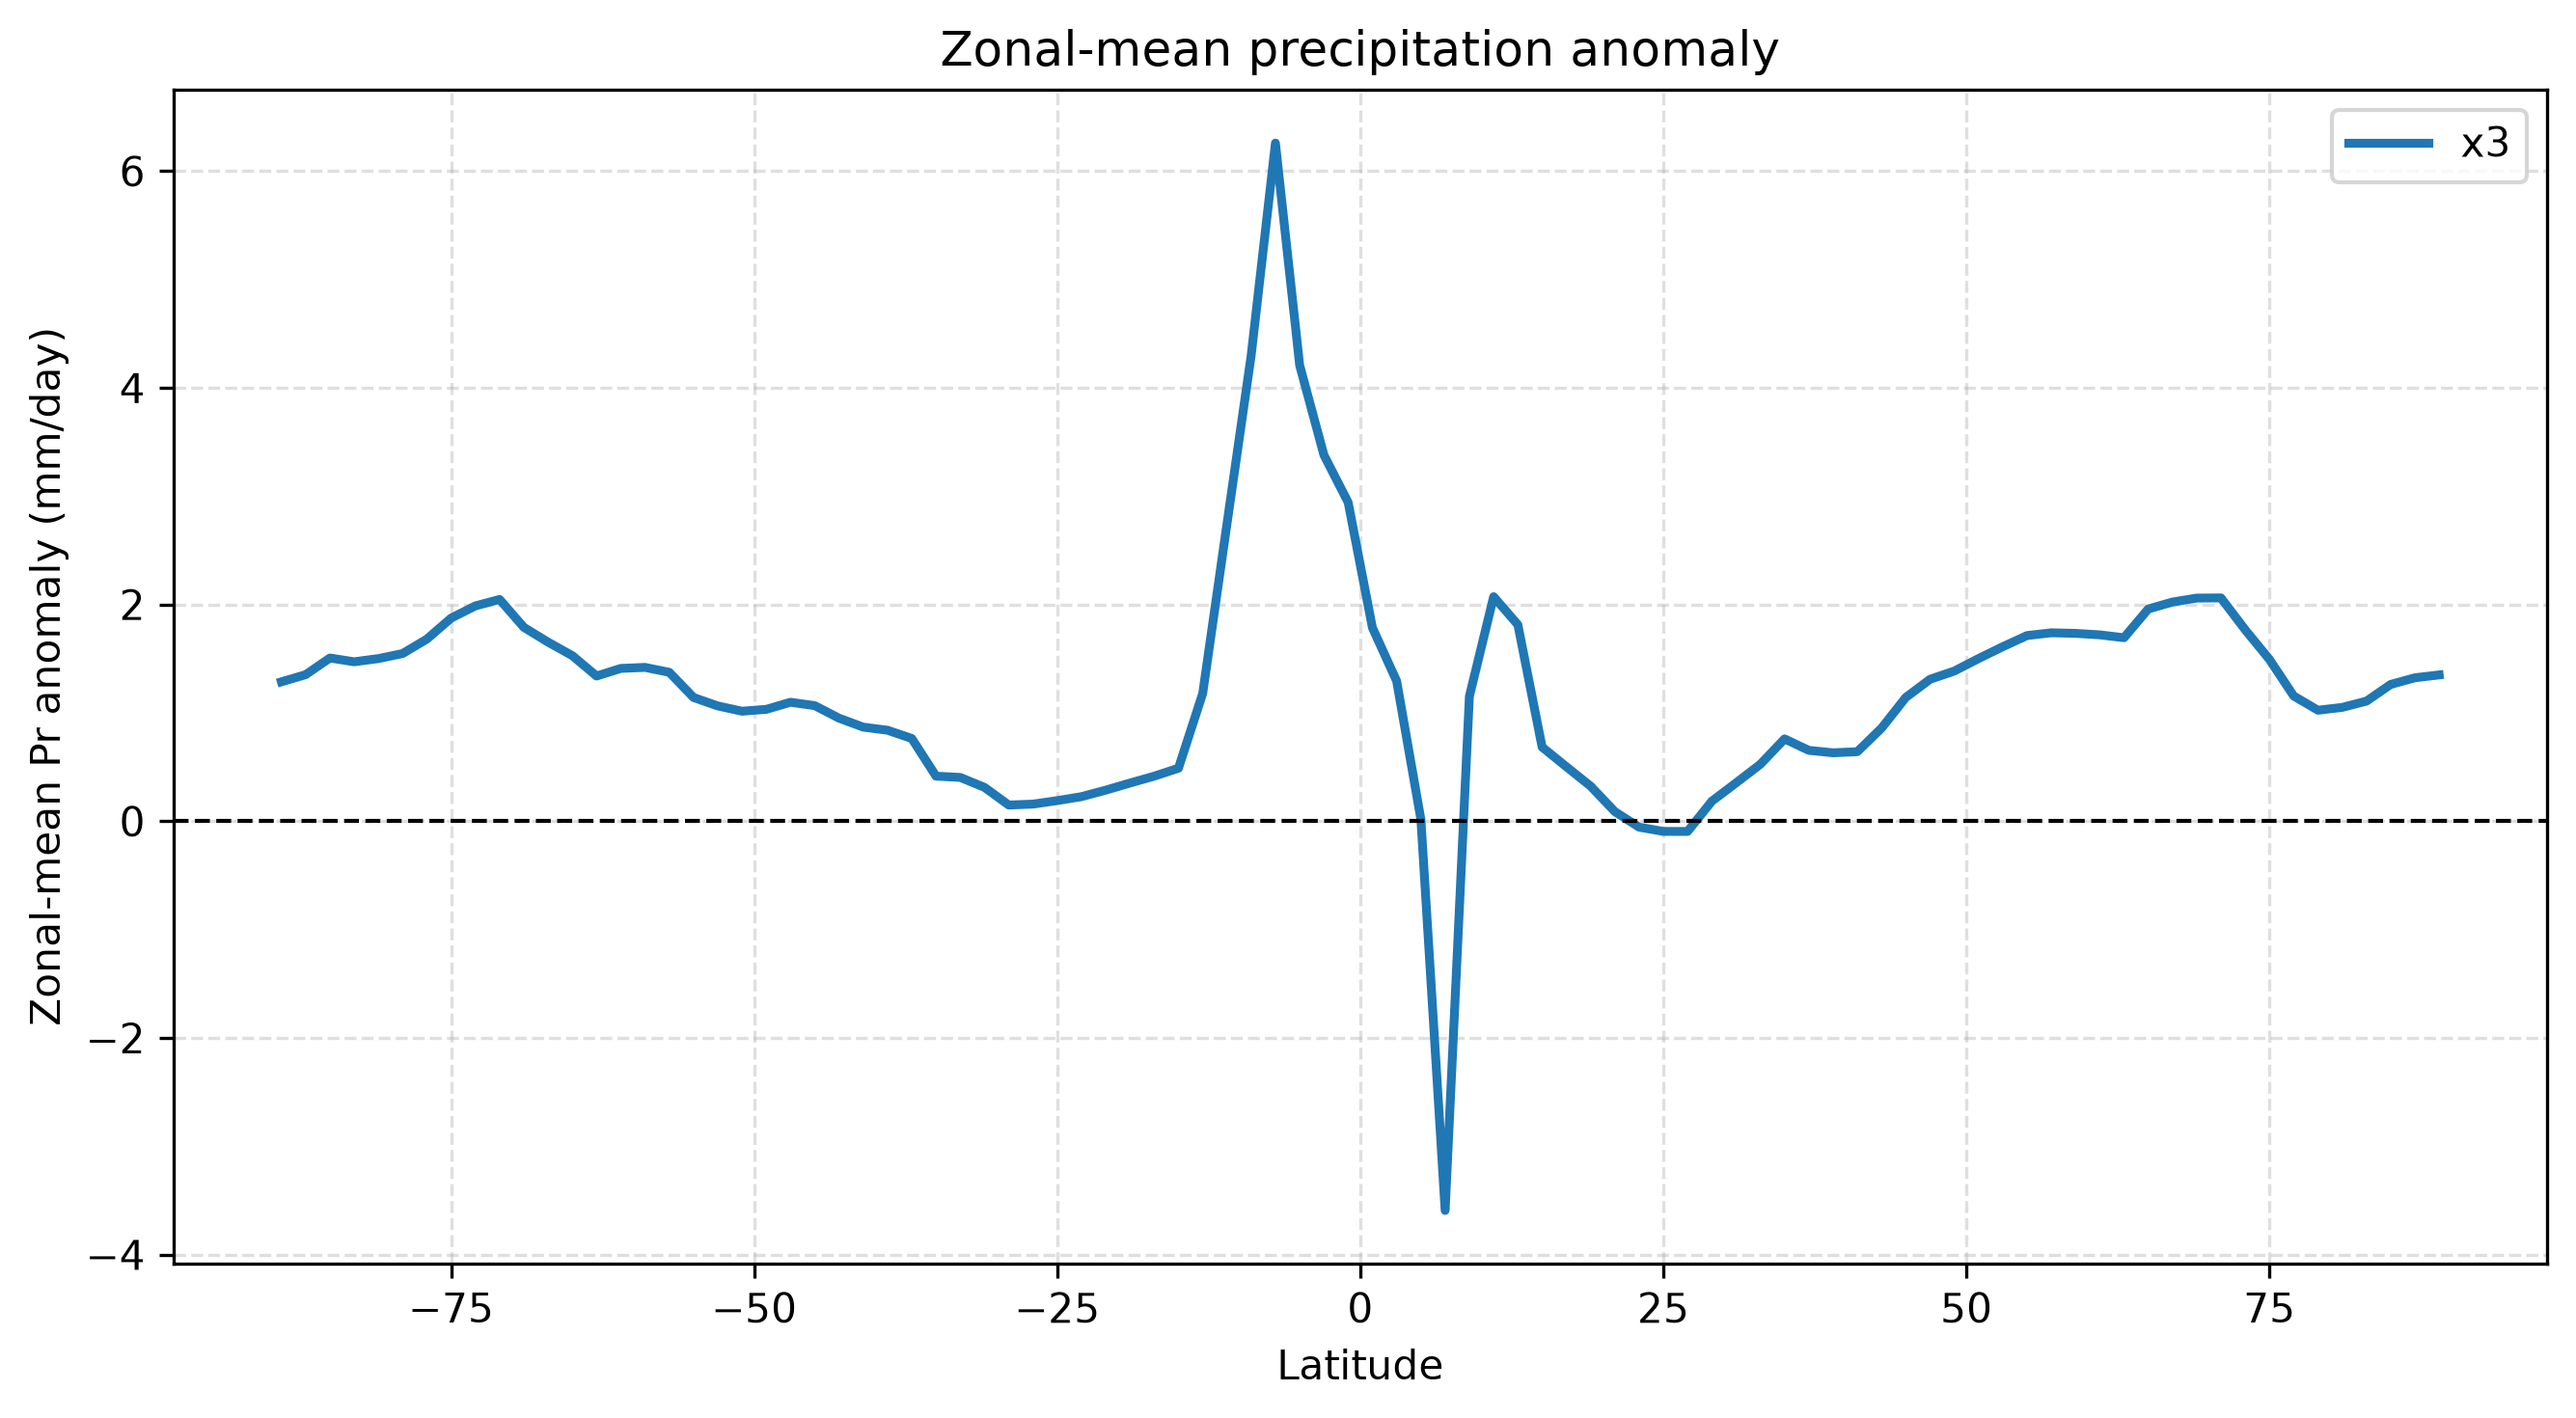

In [29]:
# Zonal mean annual PR anomalies
plot_zonal_anomalies(
    anomalies=pr_zonal_anom,
    title="Zonal-mean precipitation anomaly",
    ylabel="Zonal-mean Pr anomaly (mm/day)",
    save="pr_zonal_anom.png"
)

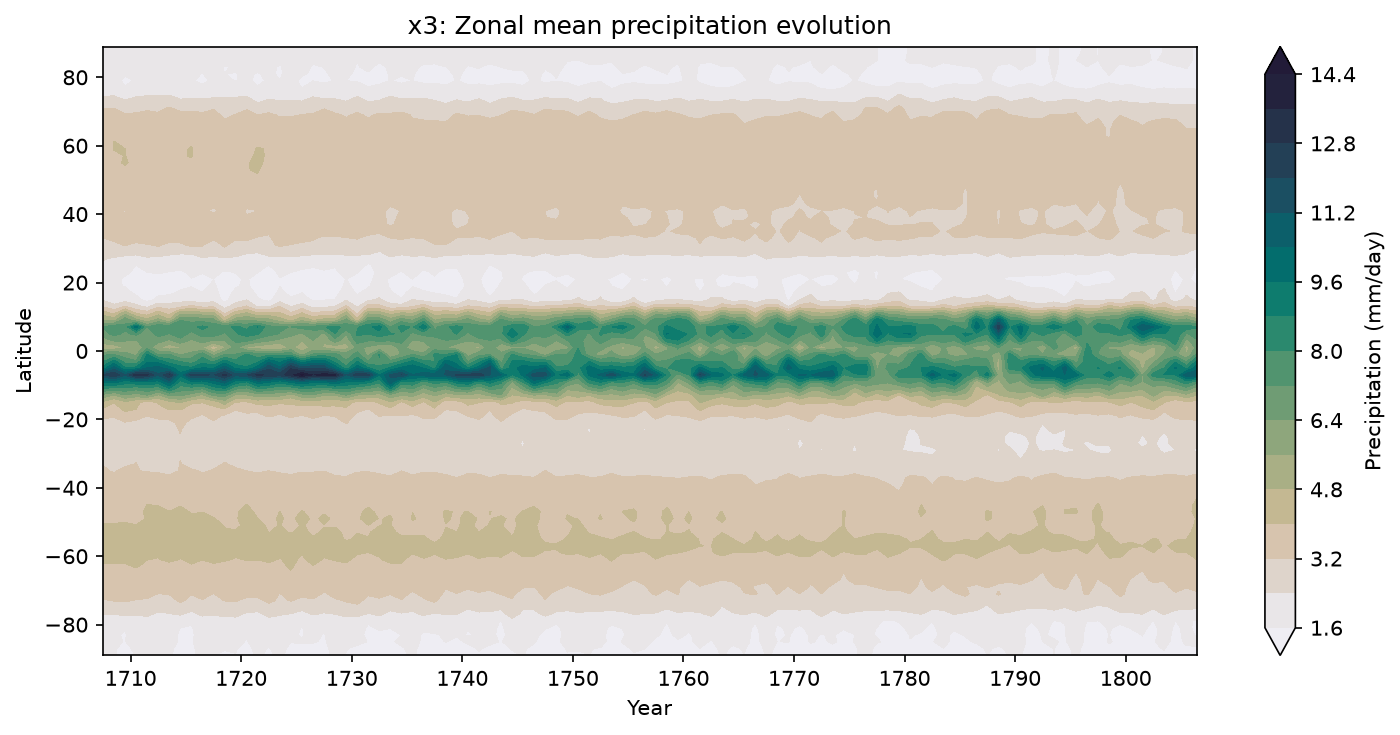

In [31]:
# Zonal mean Pr time series for one experiment
plot_zonal_time(
    field=pr_zonal_ts["x3"],
    experiment="x3",
    title="Zonal mean precipitation evolution",
    cmap=cmocean.cm.rain,
    colorbar_label="Precipitation (mm/day)",
    levels=20,
    save="pr_zonal_time_x3.png"
)

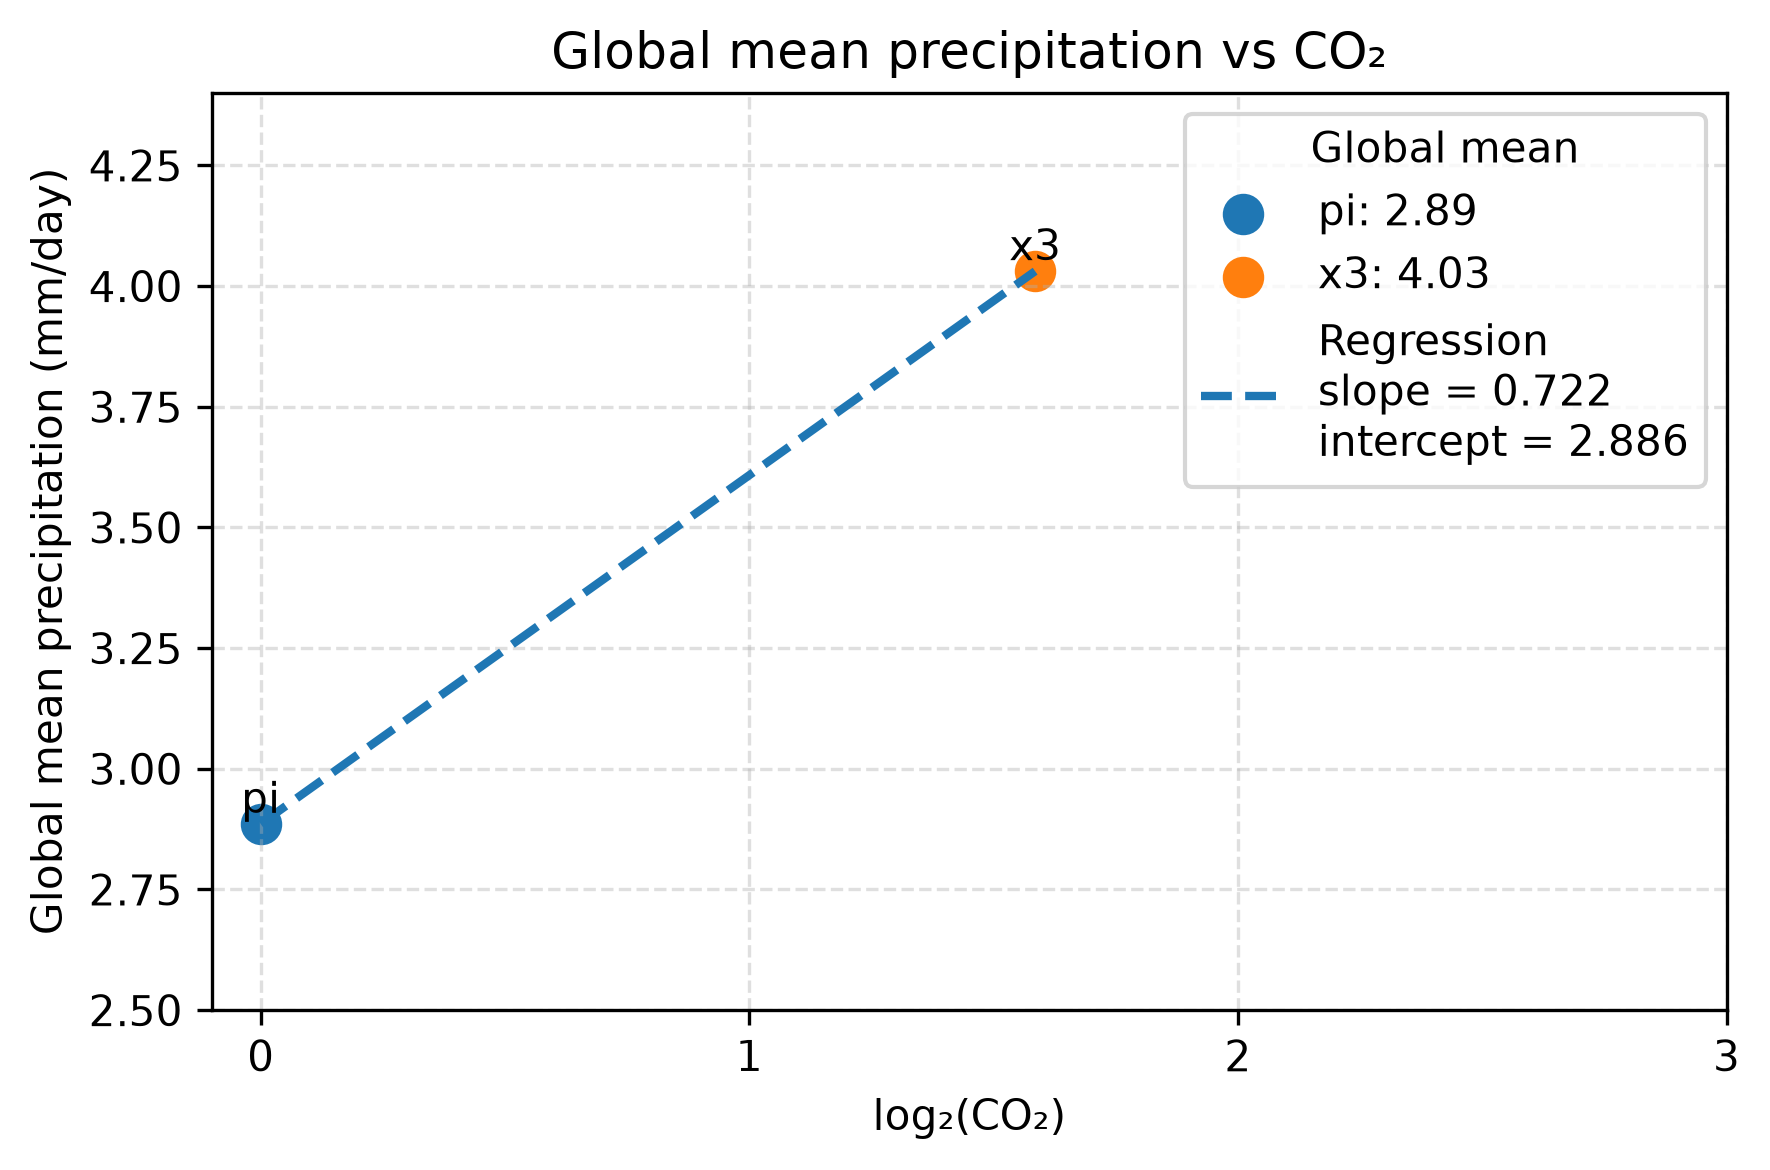

In [26]:
slope_pr, intercept_pr = plot_global_mean_vs_logco2(
    values=pr_global_mean,
    co2_levels=co2_levels,
    ylabel="Global mean precipitation (mm/day)",
    xlabel="log₂(CO₂)",
    title="Global mean precipitation vs CO₂",
    ylim=(2.5, 4.4),
    xlim=(-0.1, 3),
    save="global_mean_pr_logco2.png"
)